In [1]:
"""
WEEK 3

This assignment has 4 parts:

1. Use this notebook to read in the training data and do an initial EDA (Exploratory data analysis). I'll keep this open ended, but try to understand the data on some level. For example, look at the distribution of labels, looks at a few examples of headlines, look at dates, etc. Try to get an intuitive understanding of the data.

2. Build a multi-class classifier model in this notebook. You can build this however you want - the only rule for the competition is to use CountVectorizer() in your final model in some way for vectorizing your data. But feel free to use it however you'd like. On top of that feel free to use any supervised learning model you'd like for classifying. Scikit learn is a great place to look but doesn't have to be from scikit-learn.

3. Include a short paragraph or so in your notebook discussing interesting findings from your model. What did it do well on? What did it not do well on? Why is this the case? This is the "explainability" part of a model. Provide metrics.

4. Apply the chosen model to the judge data set provided - "news_category_judge_data_wo_label.csv". This is the "predictive" part of the model.

Format for saving:
- Save as a csv file with two columns: 'id' (given in the judge data set) and 'prediction'.
- Call the file "{your_first_name}_{your_last_name}_week_3_submission.csv"

Send me the submission csv file via email when done. Save this notebook to your repo and add me to a PR.
"""

'\nWEEK 3\n\nThis assignment has 4 parts:\n\n1. Use this notebook to read in the training data and do an initial EDA (Exploratory data analysis). I\'ll keep this open ended, but try to understand the data on some level. For example, look at the distribution of labels, looks at a few examples of headlines, look at dates, etc. Try to get an intuitive understanding of the data.\n\n2. Build a multi-class classifier model in this notebook. You can build this however you want - the only rule for the competition is to use CountVectorizer() in your final model in some way for vectorizing your data. But feel free to use it however you\'d like. On top of that feel free to use any supervised learning model you\'d like for classifying. Scikit learn is a great place to look but doesn\'t have to be from scikit-learn.\n\n3. Include a short paragraph or so in your notebook discussing interesting findings from your model. What did it do well on? What did it not do well on? Why is this the case? This is

In [1]:
# Some imports to get you started if you want. You don't need to use any of these except CountVectorizer and probably pandas
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression\

from sklearn.feature_extraction.text import CountVectorizer



In [2]:
data = pd.read_csv("news_category_data/news_category_data.csv", na_filter=False)

# 1. EDA

In [4]:
data.head()

,link,headline,category,short_description,authors,date
0,https://www.huffingtonpost.com/entry/how-trust...,How Trusting Your Gut Can Increase Wellbeing,WELLNESS,"Numerous studies, for example, have shown that...","Lissa M. Cowan, Contributor\nWriter, Teacher, ...",2013-11-27
1,https://www.huffingtonpost.com/entry/marc-chag...,Marc Chagall Birthday: Celebrating The Dreamy ...,"ARTS, CULTURE, & ENTERTAINMENT","In honor of Marc Chagall's birthday, we are re...",,2013-07-07
2,https://www.huffingtonpost.com/entry/interview...,Interview With a Meal Planner,WELLNESS,"Sure, I'm a dietitian/nutritionist and the com...","Dawn Jackson Blatner, RDN, CSSD, Contributor\n...",2014-01-09
3,https://www.huffingtonpost.com/entry/love-lett...,Love Letters: Kenai Peninsula,TRAVEL,"Alas, as it turned out I returned only for vis...","Love Letters, Contributor\nAn anthology of ref...",2013-12-18
4,https://www.huffingtonpost.com/entry/american-...,American The U.S. Holds 'Incommunicado' Wants ...,POLITICS,"""John Doe,"" a suspected ISIS fighter, has been...",Ryan J. Reilly,2018-01-05


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99824 entries, 0 to 99823
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   link               99824 non-null  object
 1   headline           99824 non-null  object
 2   category           99824 non-null  object
 3   short_description  99824 non-null  object
 4   authors            99824 non-null  object
 5   date               99824 non-null  object
dtypes: object(6)
memory usage: 4.6+ MB


In [6]:
data['category'].value_counts()

category
POLITICS                          21222
WELLNESS                          14614
ARTS, CULTURE, & ENTERTAINMENT    12580
PARENTING                          7528
STYLE & BEAUTY                     7215
TRAVEL                             5879
INTERNATIONAL NEWS                 5701
FOOD & DRINK                       3811
QUEER VOICES                       3774
SPORTS                             2972
HOME & LIVING                      2561
ENVIRONMENT                        2395
WEDDINGS                           2138
DIVORCE                            2010
RELIGION                           1537
EDUCATION                          1313
SCIENCE                            1308
TECH                               1266
Name: count, dtype: int64

In [7]:
data['headline'].head()

0         How Trusting Your Gut Can Increase Wellbeing
1    Marc Chagall Birthday: Celebrating The Dreamy ...
2                        Interview With a Meal Planner
3                        Love Letters: Kenai Peninsula
4    American The U.S. Holds 'Incommunicado' Wants ...
Name: headline, dtype: object

In [8]:
data['short_description'].head()

0    Numerous studies, for example, have shown that...
1    In honor of Marc Chagall's birthday, we are re...
2    Sure, I'm a dietitian/nutritionist and the com...
3    Alas, as it turned out I returned only for vis...
4    "John Doe," a suspected ISIS fighter, has been...
Name: short_description, dtype: object

In [9]:
data['date'].sort_values().head()

80391    2012-01-28
34537    2012-01-28
64267    2012-01-28
61724    2012-01-28
55508    2012-01-28
Name: date, dtype: object

In [10]:
data['date'].sort_values().tail()

65470    2022-09-21
91002    2022-09-21
95666    2022-09-21
32833    2022-09-21
25218    2022-09-23
Name: date, dtype: object

In [11]:
data['date'] = pd.to_datetime(data['date'])
out = data.groupby(data['date'].dt.year)['category'].value_counts().reset_index(name='count').groupby('date').head(3)
out.to_csv('yearly_category_counts.csv', index=False)

# 2. Classifier

In [12]:
ngrams = {(1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)}
classWeights = {None, 'balanced'}
columns = {'headline', 'short_description'}
best_score = 0
best_params = None
best_column = None
print("Starting")
for ngram in ngrams:
    for cw in classWeights:
        for column in columns:
            clf = CountVectorizer(stop_words='english', ngram_range=ngram)
            corpus = data[column]
            X = clf.fit_transform(corpus)
            y = data['category']
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            model = LogisticRegression(max_iter=2000, class_weight=cw, solver = 'saga')
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            score = report['weighted avg']['f1-score']
            print(f"Finished ngram: {ngram} class_weight: {cw} column: {column} score: {score}")
            if score > best_score:
                best_score = score
                best_params = (ngram, cw, column)
                print(f"New best score: {best_score} with ngram {ngram} and class_weight {cw} on column {column}")
print(f"Best parameters: ngram {best_params[0]}, class_weight {best_params[1]} , column {best_params[2]} with score {best_score}")

Starting
Finished ngram: (2, 3) class_weight: balanced column: headline score: 0.5199218707803523
New best score: 0.5199218707803523 with ngram (2, 3) and class_weight balanced on column headline
Finished ngram: (2, 3) class_weight: balanced column: short_description score: 0.3664114089805337
Finished ngram: (2, 3) class_weight: None column: headline score: 0.475775451484314
Finished ngram: (2, 3) class_weight: None column: short_description score: 0.2953189658745933
Finished ngram: (1, 2) class_weight: balanced column: headline score: 0.7362113841988909
New best score: 0.7362113841988909 with ngram (1, 2) and class_weight balanced on column headline
Finished ngram: (1, 2) class_weight: balanced column: short_description score: 0.5731272858098565
Finished ngram: (1, 2) class_weight: None column: headline score: 0.7299783548355847
Finished ngram: (1, 2) class_weight: None column: short_description score: 0.5665578099696236
Finished ngram: (3, 3) class_weight: balanced column: headline s

/Users/cameronswapp/nlp_course_assignments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Finished ngram: (1, 1) class_weight: balanced column: headline score: 0.7176356053373367
Finished ngram: (1, 1) class_weight: balanced column: short_description score: 0.5520857967418744
Finished ngram: (1, 1) class_weight: None column: headline score: 0.7227246490084004
Finished ngram: (1, 1) class_weight: None column: short_description score: 0.5537554515510087
Finished ngram: (1, 3) class_weight: balanced column: headline score: 0.7331832042955152
Finished ngram: (1, 3) class_weight: balanced column: short_description score: 0.5685215545302132
Finished ngram: (1, 3) class_weight: None column: headline score: 0.7209202354219412
Finished ngram: (1, 3) class_weight: None column: short_description score: 0.5594047569080164
Best parameters: ngram (1, 2), class_weight balanced , column headline with score 0.7362113841988909


In [8]:
# Best model

best_params = ((1, 2), 'balanced', 'headline')

best_ngram, best_cw, best_column = best_params
clf = CountVectorizer(stop_words='english', ngram_range=best_ngram)
corpus = data[best_column]
X = clf.fit_transform(corpus)
y = data['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = LogisticRegression(max_iter=2000, class_weight=best_cw)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

                                precision    recall  f1-score   support

ARTS, CULTURE, & ENTERTAINMENT       0.77      0.70      0.74      2609
                       DIVORCE       0.68      0.68      0.68       383
                     EDUCATION       0.48      0.55      0.51       274
                   ENVIRONMENT       0.57      0.57      0.57       489
                  FOOD & DRINK       0.72      0.76      0.74       747
                 HOME & LIVING       0.75      0.73      0.74       498
            INTERNATIONAL NEWS       0.68      0.69      0.68      1065
                     PARENTING       0.68      0.70      0.69      1500
                      POLITICS       0.88      0.80      0.84      4201
                  QUEER VOICES       0.73      0.69      0.71       735
                      RELIGION       0.56      0.54      0.55       304
                       SCIENCE       0.60      0.54      0.57       278
                        SPORTS       0.73      0.70      0.72  

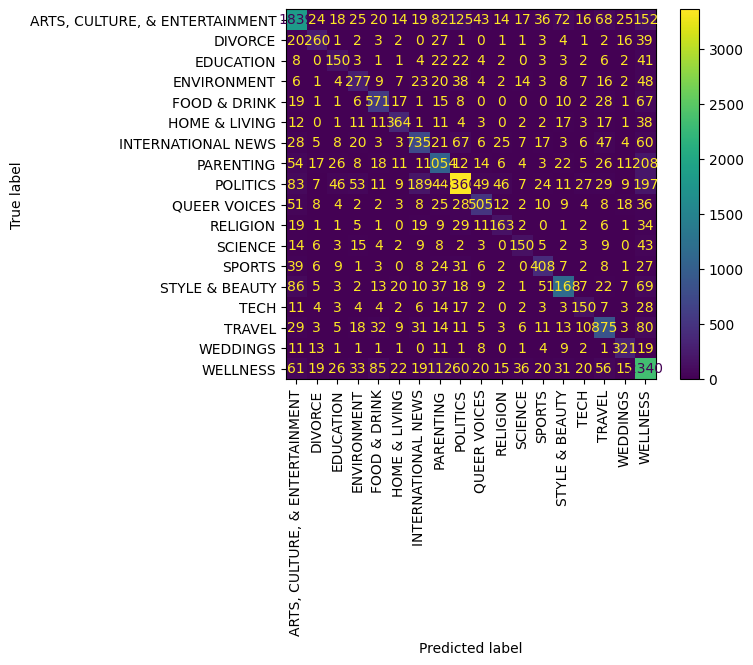

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(xticks_rotation='vertical')
plt.show()

# 3. Interpretation

The model that I built did pretty well overall, achieving a weighted average F1 score of 0.74. The model did particularly well in classes with many observations. In classes with at least 500 observations in the test set, the lowest class F1 score is 0.68, with the majority of these scores being well over 0.7. However, in classes with less than 500 observations in the test set, the class F1 scores are as low as 0.51 and rarely exceed 0.7. This isn't super surprising, because fewer observations of a class in the test set likely means that there are fewer observations of these classes in the training set. Because the model didn't see as many examples of these classes during training, this is likely why the F1 scores tend to be lower in classes with fewer observations.

This is also shown in the difference between the macro F1 score and the weighted average F1 score. The macro F1 score treats all classes equally, so the smaller classes with lower scores have a bigger impact on the score reported, which is 0.68 for this model. The weighted average F1 score is 0.74, which is brought up by higher scores from the larger classes. Specifically, for the 'Politics' category which had the most observations, the F1 score is 0.84, which is achieved because of so many training examples in this category.

An interesting result is from the 'Weddings' category. There are only 405 observations of this category in the test set, but the F1 score for the category is 0.76. I would imagine that this is because headlines about weddings often use words rarely used in other caterogies' headlines. On the other side of the coin, 'International News' has over 1000 observations in the test set, but an F1 score of only 0.68. However, this makes sense because international news likely covers many topics and the model would confuse the headlines for these other topics.

# 4. Judge Set

In [10]:
judge_data = pd.read_csv("news_category_data/news_category_judge_data_wo_label.csv", na_filter=False)

judge_corpus = judge_data[best_column]
judge_X = clf.transform(judge_corpus)
judge_predictions = best_model.predict(judge_X)

submission = pd.DataFrame({'id': judge_data['id'], 'prediction': judge_predictions})

submission.to_csv("Cameron_Swapp_week_3_submission.csv", index=False)